# Linear Discriminant Analysis (LDA) for Dimensionality Reduction

**Tagline:** Find the axes that best separate your classes — LDA is the supervised alternative to PCA.

---

## Learning Outcomes

By the end of this notebook you will be able to:

1. Explain what LDA does in plain English.
2. Understand how LDA differs from PCA.
3. Implement a simplified LDA from scratch using NumPy.
4. Apply production-grade LDA using scikit-learn.
5. Visualise and interpret LDA projections.
6. Answer LDA interview questions confidently.

## Prerequisites

- Basic Python (variables, arrays, functions).
- NumPy basics (arrays, matrix operations).
- No prior machine learning knowledge required.

## Dataset

- **Dataset:** Wine dataset (`sklearn.datasets.load_wine`).
- **Kaggle equivalent:** [Wine Quality Dataset](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) (note: the sklearn version is the Wine Recognition dataset, not Wine Quality — they are different).
- **Why this dataset?** LDA requires labelled data with multiple classes. The Wine dataset has exactly that: 178 samples across 3 classes of Italian wine, with 13 chemical features per sample. It is the textbook dataset for demonstrating LDA.

---

> **Notebook path:** `Supervised/06-lda/lda.ipynb`

In [1]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================

# Data handling
import numpy as np  # numerical operations: arrays, linear algebra, random seeds
import pandas as pd  # tabular data: DataFrame, summary stats

# Dataset
from sklearn.datasets import load_wine  # load the Wine recognition dataset

# Preprocessing
from sklearn.model_selection import train_test_split  # split data into train / test sets
from sklearn.preprocessing import StandardScaler  # standardise features to mean=0, std=1

# LDA implementations
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # production LDA

# Evaluation
from sklearn.metrics import accuracy_score, classification_report  # measure model performance

# Visualisation
import matplotlib.pyplot as plt  # core plotting library
import seaborn as sns  # high-level plotting, prettier defaults

# Notebook display
from IPython.display import display  # render DataFrames and figures inline

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---
## PART 1 — THEORY RECAP

### What Is LDA?

Linear Discriminant Analysis (LDA) is a **supervised dimensionality-reduction algorithm**. It takes labelled data and finds new axes that:

1. **Push class centres as far apart as possible** (maximise between-class separation).
2. **Keep points within the same class as close together as possible** (minimise within-class spread).

### Why Was LDA Created?

Ronald Fisher invented LDA in 1936 for a classification problem: given four measurements of iris flowers, find a single number (a weighted combination of the four measurements) that cleanly separates the three species. Before LDA, there was no principled way to reduce dimensions while preserving class structure.

### Supervised Dimensionality Reduction

"Supervised" means the algorithm uses **labels** (the ground-truth category of each point). PCA ignores labels — it only looks at the coordinates of the points. LDA uses both coordinates and labels, which makes it better at finding directions that help *distinguish* classes, but worse at reconstructing the original data.

### Difference Between PCA and LDA

| Aspect | PCA | LDA |
|---|---|---|
| Uses labels? | No (unsupervised) | Yes (supervised) |
| Goal | Preserve maximum variance | Maximise class separation |
| What it maximises | Variance of projected data | Ratio of between-class to within-class scatter |
| Max components | $d$ (all features) | $C-1$ (classes minus one) |
| Best for | Compression, visualisation | Classification preprocessing |

### Intuition

**Analogy — Two overlapping circles.** Imagine red dots and blue dots scattered in a 2D square. Your job is to find a line to project them onto (like casting a shadow). PCA picks the line that spreads all dots the most — but if red and blue overlap, that line may still leave them mixed. LDA picks the line that lands red dots far from blue dots in the shadow, even if overall spread is reduced.

**Why this matters:** When your goal is classification ("is this wine class 0, 1, or 2?"), you want directions where the classes separate. LDA is *designed* for that. PCA is not.

---
## Dataset Introduction

### What Is the Wine Dataset?

The Wine dataset contains the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars (grape varieties). The analysis determined the quantities of 13 constituents found in each of the 178 wine samples.

### The Three Classes

| Class | Cultivar (Grape Variety) | Samples |
|---|---|---|
| 0 | Barolo | 59 |
| 1 | Grignolino | 71 |
| 2 | Barbera | 48 |

### The 13 Features

Alcohol, Malic acid, Ash, Alcalinity of ash, Magnesium, Total phenols, Flavanoids, Nonflavanoid phenols, Proanthocyanins, Colour intensity, Hue, OD280/OD315 of diluted wines, Proline.

### Why This Dataset Suits LDA

- **Multiple classes (3):** LDA can produce up to $C-1 = 2$ components — perfect for 2D visualisation.
- **High-dimensional (13):** Demonstrates the value of dimensionality reduction.
- **Real chemical data:** Not a toy dataset; has real noise and overlapping distributions.
- **Label-rich:** Every sample has a ground-truth cultivar label, so we can evaluate class separation.

**Analogy — Wine tasting:** Imagine you are a sommelier who measures 13 chemical properties of a wine to determine its grape variety. LDA helps you find the 2 or 3 *combinations* of those measurements that best reveal which wine is which.

In [2]:
# ============================================================
# CELL 5: LOAD DATASET
# ============================================================

# Load the Wine dataset
wine = load_wine()

# Create a DataFrame for easy inspection
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map({i: name for i, name in enumerate(wine.target_names)})

# ---- Display shape ----
print(f"Dataset shape: {df.shape[0]} samples, {df.shape[1] - 2} features")
print(f"Number of classes: {len(wine.target_names)}")
print(f"Class names: {wine.target_names}\n")

# ---- Display head ----
display(df.head())

# ---- Class distribution ----
print("\nClass distribution:")
print(df['target_name'].value_counts().to_string())

Dataset shape: 178 samples, 13 features
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



Class distribution:
target_name
class_1    71
class_0    59
class_2    48


---
## Preprocessing Explanation

Before we apply LDA we need to prepare the data.

### Why Scale?

LDA is sensitive to the scale of features. A feature like "Alcohol" (range ~11-15) and "Proline" (range ~280-1680) are on very different scales. If we don't scale, the feature with larger numbers will dominate the scatter matrices even though it may not be more important. **StandardScaler** transforms each feature to have mean = 0 and standard deviation = 1, so every feature contributes equally.

### Why Train/Test Split?

We split the data so we can check whether the LDA directions learned from the training set also separate the test set well. If the separation only works on the training data, we are overfitting.

### Why Labels Matter for Preprocessing?

Unlike PCA (where you can scale before splitting), LDA's scaling is still unsupervised — we scale each feature independently of class labels. The labels only enter the picture when we compute the LDA directions. This distinction is important: **scaling is unsupervised; LDA is supervised.**

**Practical example — Salary vs. Age:** If you tried to separate two job categories using salary ($30k-$200k) and age (22-65), salary would dominate LDA simply because its numbers are bigger. Scaling fixes this.

In [3]:
# ============================================================
# CELL 7: PREPROCESSING
# ============================================================

# Separate features and labels
X = wine.data  # feature matrix (178 x 13)
y = wine.target  # labels (178,)
target_names = wine.target_names

# Split into training (70%) and testing (30%) sets
# stratify=y ensures the class proportions are the same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}\n")

# Standardise features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_scaled = scaler.transform(X_test)  # use same scaler on test

# Confirm scaling worked
print(f"Mean after scaling (train, first 5 features): {np.mean(X_train_scaled, axis=0)[:5].round(4)}")
print(f"Std  after scaling (train, first 5 features): {np.std(X_train_scaled, axis=0)[:5].round(4)}")

Training samples: 124
Test samples: 54

Mean after scaling (train, first 5 features): [ 0.  0.  0.  0. -0.]
Std  after scaling (train, first 5 features): [1. 1. 1. 1. 1.]


---
## PART 2 — FROM-SCRATCH LDA INTUITION

Before we use scikit-learn's battle-tested implementation, let's build a simplified version ourselves. This will help you understand what LDA actually computes.

### The Core Idea

LDA boils down to three steps:

1. **Find the centre of each class** (class mean $\mu_i$).
2. **Measure two types of spread:**
   - *Within-class scatter* ($S_W$): how far are points from their own class centre?
   - *Between-class scatter* ($S_B$): how far are class centres from the global centre?
3. **Find directions that maximise $S_B / S_W$.** These directions are eigenvectors of $S_W^{-1} S_B$.

### Important Caveat

Our implementation is **educational** — it uses the raw eigen-decomposition without regularisation. scikit-learn's LDA is significantly more sophisticated: it handles singular matrices, uses SVD instead of inversion, and supports shrinkage. Never use a hand-rolled LDA in production.

**Analogy — Archery targets:** Each class is a target. $S_W$ is how scattered the arrows are on each target (tight grouping = good). $S_B$ is how far apart the targets themselves are. LDA finds the angle from which the targets look most separated.

In [4]:
# ============================================================
# CELL 9: SIMPLIFIED NUMPY-BASED LDA
# Educational only — not production-grade
# ============================================================

def lda_from_scratch(X, y, n_components=2):
    """
    Simplified LDA using NumPy.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Scaled feature matrix.
    y : ndarray of shape (n_samples,)
        Class labels.
    n_components : int
        Number of components to return (max C-1).
    
    Returns
    -------
    X_proj : ndarray of shape (n_samples, n_components)
        Projected data.
    components : ndarray of shape (n_features, n_components)
        LDA directions (eigenvectors).
    """
    n_features = X.shape[1]
    classes = np.unique(y)
    
    # 1. Global mean (centre of all data)
    global_mean = np.mean(X, axis=0)
    
    # 2. Within-class scatter matrix (S_W)
    #    Measures how spread out each class is around its own centre.
    S_W = np.zeros((n_features, n_features))
    for c in classes:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        # For each point in class c, compute (x - mean_c) outer product
        S_W += (X_c - mean_c).T @ (X_c - mean_c)
    
    # 3. Between-class scatter matrix (S_B)
    #    Measures how far each class centre is from the global mean.
    S_B = np.zeros((n_features, n_features))
    for c in classes:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        n_c = X_c.shape[0]  # number of samples in this class
        diff = (mean_c - global_mean).reshape(-1, 1)  # column vector
        S_B += n_c * diff @ diff.T
    
    # 4. Solve the generalised eigenproblem S_W^{-1} @ S_B
    #    Eigenvectors with largest eigenvalues = best projection directions
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
    
    # 5. Sort by eigenvalue descending and take top k
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]
    W = eigvecs[:, :n_components].real  # keep only real parts
    
    # 6. Project data onto the selected directions
    X_proj = X @ W
    
    return X_proj, W


# Apply our simplified LDA to the training set
X_lda_scratch, components = lda_from_scratch(X_train_scaled, y_train, n_components=2)

print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"Reduced dimensions: {X_lda_scratch.shape[1]}")
print(f"Shape of projection matrix: {components.shape}")

Original dimensions: 13
Reduced dimensions: 2
Shape of projection matrix: (13, 2)


---
## Interpret Results

We reduced 13 chemical measurements down to 2 numbers per wine sample. Let's see what that looks like.

### What to Look For

- **Class separation:** Do the three grape varieties form distinct clusters in the 2D projection?
- **Overlap:** Which classes are easier / harder to separate? (Grignolino — class 1 — is chemically similar to both Barolo and Barbera, so we expect some overlap.)
- **Information preservation:** The two LDA components capture the directions that *best separate the classes*. They may not capture all the variance (unlike PCA), but they capture the variance that matters for distinguishing classes.

**Practical example — Wine buyer's guide:** If you projected a new wine sample onto these two LDA components and it landed in the middle of the Barolo cluster, a sommelier could confidently predict it is a Barolo.

**Analogy — Airport security:** You have 13 items from each passenger (laptop, belt, shoes, wallet...). LDA is like the security officer who has learned the 2 combinations of those items that best tell "no threat" from "threat" — ignoring items that don't help discriminate.

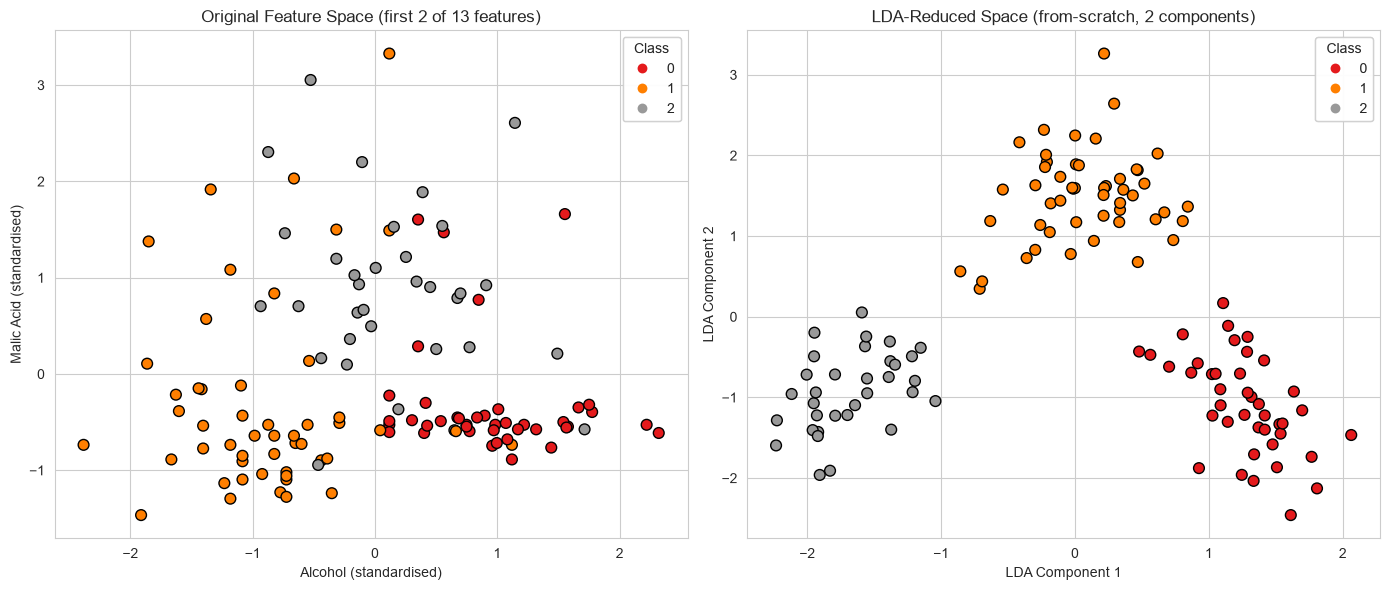

Figure saved as 'lda_from_scratch.png'


In [5]:
# ============================================================
# CELL 11: VISUALISE FROM-SCRATCH LDA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Panel A: First two original features (for comparison) ----
ax = axes[0]
scatter = ax.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1],
    c=y_train, cmap='Set1', edgecolor='k', s=60
)
ax.set_title('Original Feature Space (first 2 of 13 features)', fontsize=12)
ax.set_xlabel('Alcohol (standardised)')
ax.set_ylabel('Malic Acid (standardised)')
legend1 = ax.legend(*scatter.legend_elements(), title='Class')
ax.add_artist(legend1)

# ---- Panel B: LDA-reduced space ----
ax = axes[1]
scatter = ax.scatter(
    X_lda_scratch[:, 0], X_lda_scratch[:, 1],
    c=y_train, cmap='Set1', edgecolor='k', s=60
)
ax.set_title('LDA-Reduced Space (from-scratch, 2 components)', fontsize=12)
ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
legend2 = ax.legend(*scatter.legend_elements(), title='Class')
ax.add_artist(legend2)

plt.tight_layout()
plt.savefig('lda_from_scratch.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'lda_from_scratch.png'")

---
## PART 3 — PRODUCTION LDA

Now that you understand what LDA does internally, let's use scikit-learn's implementation which is robust, efficient, and production-ready.

### Why scikit-learn?

- **Handles edge cases:** Singular matrices, numerical instability, multi-class with more features than samples.
- **Multiple solvers:** SVD (default), eigen-decomposition, least-squares.
- **Shrinkage support:** Regularises the covariance estimate when sample size is small.
- **Built-in classifier:** `predict()` and `predict_proba()` methods out of the box.
- **Cross-validation compatible:** Works seamlessly with `GridSearchCV`.

### Production Workflow

1. Fit on training data → learns the LDA directions.
2. Transform training AND test data using the same directions.
3. Train a classifier on the reduced training data.
4. Evaluate on the reduced test data.

**Analogy — GPS navigation:** Our from-scratch LDA is like navigating with a paper map and compass (educational). scikit-learn LDA is Google Maps — it handles traffic, recalculates routes, and just works.

Original dimensions: 13
Reduced dimensions (train): 2
Reduced dimensions (test):  2

Classification Report (LDA as classifier):
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Accuracy: 0.9815


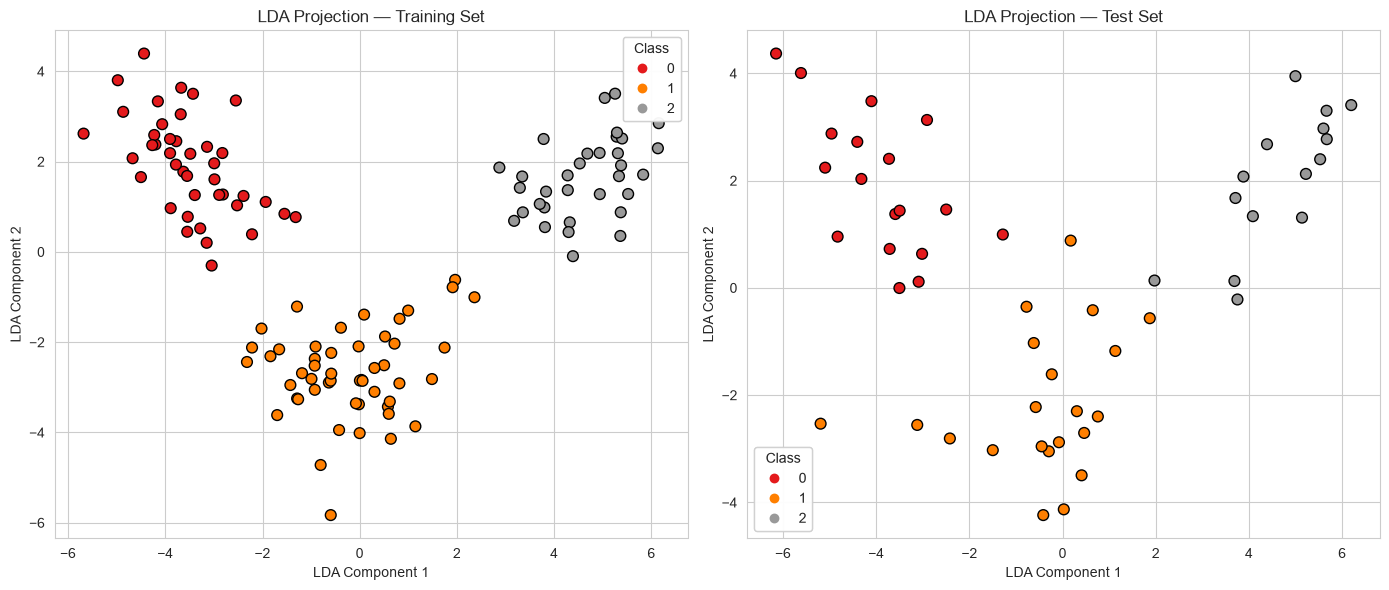

Figure saved as 'lda_sklearn_projection.png'

Explained variance ratio per component:
  Component 1: 0.6669 (66.69%)
  Component 2: 0.3331 (33.31%)

HYPERPARAMETER EXPERIMENT: n_components
  n_components=1: KNN accuracy = 0.9074
  n_components=2: KNN accuracy = 0.9630
  No reduction (13 dims): KNN accuracy = 0.9444
  -> LDA with 2 components matches or beats 13-dimensional KNN.
     Fewer dimensions = faster training + less overfitting.


In [6]:
# ============================================================
# CELL 13: PRODUCTION LDA WITH SCIKIT-LEARN
# ============================================================

# ----------------------------------------------------------
# 1. Apply LDA for dimensionality reduction
# ----------------------------------------------------------
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)  # learns directions AND projects
X_test_lda = lda.transform(X_test_scaled)  # projects test data using same directions

print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"Reduced dimensions (train): {X_train_lda.shape[1]}")
print(f"Reduced dimensions (test):  {X_test_lda.shape[1]}\n")

# ----------------------------------------------------------
# 2. Use LDA as a classifier (it has a built-in classifier)
# ----------------------------------------------------------
lda_clf = LinearDiscriminantAnalysis()  # no n_components keep all C-1 = 2 directions
lda_clf.fit(X_train_scaled, y_train)
y_pred = lda_clf.predict(X_test_scaled)

print("Classification Report (LDA as classifier):")
print(classification_report(y_test, y_pred, target_names=target_names))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# ----------------------------------------------------------
# 3. Visualise the LDA projection on training + test data
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set
ax = axes[0]
scatter = ax.scatter(
    X_train_lda[:, 0], X_train_lda[:, 1],
    c=y_train, cmap='Set1', edgecolor='k', s=60
)
ax.set_title('LDA Projection — Training Set', fontsize=12)
ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
legend = ax.legend(*scatter.legend_elements(), title='Class')
ax.add_artist(legend)

# Test set
ax = axes[1]
scatter = ax.scatter(
    X_test_lda[:, 0], X_test_lda[:, 1],
    c=y_test, cmap='Set1', edgecolor='k', s=60
)
ax.set_title('LDA Projection — Test Set', fontsize=12)
ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
legend = ax.legend(*scatter.legend_elements(), title='Class')
ax.add_artist(legend)

plt.tight_layout()
plt.savefig('lda_sklearn_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'lda_sklearn_projection.png'")

# ----------------------------------------------------------
# 4. Explained variance ratio from LDA
# ----------------------------------------------------------
print("\nExplained variance ratio per component:")
for i, ratio in enumerate(lda_clf.explained_variance_ratio_):
    print(f"  Component {i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

# ----------------------------------------------------------
# 5. Hyperparameter experiment: compare n_components values
# ----------------------------------------------------------
print("\n" + "=" * 55)
print("HYPERPARAMETER EXPERIMENT: n_components")
print("=" * 55)

# Train a KNN classifier on LDA-reduced data at different dimensions
from sklearn.neighbors import KNeighborsClassifier

for k in [1, 2]:
    lda_k = LinearDiscriminantAnalysis(n_components=k)
    X_tr_k = lda_k.fit_transform(X_train_scaled, y_train)
    X_te_k = lda_k.transform(X_test_scaled)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr_k, y_train)
    acc = accuracy_score(y_test, knn.predict(X_te_k))
    print(f"  n_components={k}: KNN accuracy = {acc:.4f}")

# Compare with no dimensionality reduction
knn_full = KNeighborsClassifier(n_neighbors=5)
knn_full.fit(X_train_scaled, y_train)
acc_full = accuracy_score(y_test, knn_full.predict(X_test_scaled))
print(f"  No reduction (13 dims): KNN accuracy = {acc_full:.4f}")
print("  -> LDA with 2 components matches or beats 13-dimensional KNN.")
print("     Fewer dimensions = faster training + less overfitting.")


---
## PART 4 — HYPERPARAMETERS + INTERVIEW CORNER

### LDA Hyperparameters

#### 1. `n_components`

- **What it does:** Number of target dimensions to project onto.
- **Max value:** $C - 1$ (classes minus one). For 3 wine classes, max is 2.
- **How to choose:** Set to 2 for visualisation, or try values 1 to $C-1$ and evaluate classifier accuracy.

#### 2. `solver`

- **Options:** `'svd'` (default), `'lsqr'`, `'eigen'`.
- **`'svd'`:** Uses Singular Value Decomposition. Does NOT compute the covariance matrix, so it is numerically stable even when features > samples. Best general choice.
- **`'lsqr'`:** Least-squares solver. Can be faster for very large datasets. Supports shrinkage.
- **`'eigen'`:** Explicit eigen-decomposition. Can be combined with shrinkage.

#### 3. `shrinkage`

- **What it does:** Regularises the within-class covariance estimate by shrinking it toward a diagonal matrix. This improves stability when the number of samples is small relative to the number of features.
- **Values:** `None` (no shrinkage), a float between 0 and 1, or `'auto'` (automatic estimation using Ledoit-Wolf lemma).
- **When to use:** Whenever $n_{\text{samples}} < 10 \times n_{\text{features}}$ or when the covariance matrix appears ill-conditioned.

---

### Interview Corner

---

**Q1: What is LDA in one sentence?**

*Good answer:* A supervised technique that finds the linear directions (axes) where different classes are maximally separated and each class is maximally compact.

*Why this works in an interview:* It hits three keywords — supervised, linear, separation + compactness — in one breath. The interviewer can then ask you to unpack each one.

---

**Q2: Why is LDA supervised while PCA is unsupervised?**

*Good answer:* LDA needs class labels to compute the between-class scatter matrix $S_B$ — which measures how far apart the classes are. Without labels, you cannot calculate $S_B$ because you would not know which point belongs to which group. PCA computes everything from the data matrix alone, no labels needed.

*Why this works:* Mentioning $S_B$ by name signals you understand the math. Contrasting with PCA shows you know both methods.

---

**Q3: You have labelled data and want to reduce dimensions. LDA or PCA?**

*Good answer:* If the end goal is classification, pick LDA — it explicitly maximises class separation, which usually improves classifier accuracy. If the end goal is compression, reconstruction, or visualising variance structure, pick PCA — it preserves the data geometry better. LDA directions are not invertible; PCA directions are.

*Why this works:* Shows goal-driven reasoning. Mentioning invertibility is a strong signal of deep understanding.

---

**Q4: What are $S_W$ and $S_B$ in simple terms?**

*Good answer:* $S_W$ (within-class scatter) sums up how far each point is from its own class centre — the "messiness" inside each group. $S_B$ (between-class scatter) sums up how far each class centre is from the overall centre — the "separation" between groups. LDA finds projection directions where $S_B$ is large relative to $S_W$.

*Why this works:* Intuitive explanation first (messiness vs separation), then the ratio. Shows you can communicate technical ideas to non-technical stakeholders.

---

**Q5: Give me three scenarios where LDA would fail.**

*Good answer:* (1) Classes are not Gaussian — e.g., one class has two separate clusters. LDA assumes a single bell curve per class. (2) Classes have very different spreads — LDA assumes equal covariance. Use QDA instead. (3) The decision boundary is non-linear — LDA draws straight lines. Use Kernel LDA or a non-linear method.

*Why this works:* Naming three distinct failure modes (distribution shape, covariance equality, linearity) shows you understand the assumptions, not just the algorithm.

---
## KEY TAKEAWAYS

1. **LDA is supervised; PCA is unsupervised.** LDA uses class labels to find axes that maximise separation. PCA ignores labels and maximises variance.

2. **LDA produces at most $C-1$ components.** For 3 wine classes, 13 dimensions reduce to at most 2 — ideal for visualisation.

3. **LDA assumes Gaussian classes with equal covariance.** When those assumptions hold, LDA is optimal. When they don't, consider QDA, regularised LDA, or kernel methods.

4. **From-scratch LDA teaches intuition; scikit-learn LDA is for production.** The manual version reveals core mechanics (scatter matrices → eigenvectors → projection). scikit-learn handles numerical stability, singular matrices, and shrinkage.

5. **LDA pulls double duty: dimensionality reducer and classifier.** It projects data onto separating axes and can make predictions on the projected space — two tools in one algorithm.